### Decision Tree Classification - Example and Exercise

#### Exercise - Decision Tree Classifier for Credit Risk Prediction

Problem Statement

* Develop a Machine Learning Classification Model that can assess the credit risk of loan applicants.

* The goal is to predict whether an applicant is 'High Risk' (1) or 'Low Risk' (0) based on their financial and personal information.

* You will use a Decision Tree model for this task because its transparent, flowchart-like structure makes it easy to explain the reasons behind a loan approval or denial to stakeholders and regulators.

Necessary Steps to be Performed

1.  Import Libraries, Load and Explore the Dataset: Import the necessary libraries, Load and Explore the dataset for credit risk analysis.
2.  Data Preprocessing: Prepare the data for the model by converting categorical features into a numerical format.
3.  Define Features and Target: Separate the dataset into feature variables (`X`) and the target variable (`y`).
4.  Split Data: Divide the data into a training set and a testing set.
5.  Create and Train Model: Instantiate a `DecisionTreeClassifier` and train it on the training data.
6.  Evaluate Model Performance: Test the model's accuracy on the unseen data.
7.  Visualize the Decision Tree: Plot the trained model to understand its decision-making logic.
8.  Make Predictions: Use the model to predict the credit risk for a new applicant.

---


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import  matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('heart_disease.csv')
df.head()

,age,cholesterol,chest_pain_type,max_heart_rate,heart_disease
0,67,286,atypical angina,122,1
1,57,293,typical angina,149,1
2,43,253,typical angina,100,1
3,71,164,typical angina,176,0
4,36,207,non-anginal pain,121,0


In [3]:
le_pain = LabelEncoder()
df['chest_pain_type_n'] = le_pain.fit_transform(df['chest_pain_type'])

print("__DataFrame after Chest Pain Type Encoding added__")
df.head()

__DataFrame after Chest Pain Type Encoding added__


,age,cholesterol,chest_pain_type,max_heart_rate,heart_disease,chest_pain_type_n
0,67,286,atypical angina,122,1,0
1,57,293,typical angina,149,1,2
2,43,253,typical angina,100,1,2
3,71,164,typical angina,176,0,2
4,36,207,non-anginal pain,121,0,1


In [4]:
X = df[['age', 'cholesterol', 'chest_pain_type_n', 'max_heart_rate']]
y = df['heart_disease']

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (250, 4)
Shape of y: (250,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Length of X_train:", len(X_train))
print("Length of X_test:", len(X_test))

Length of X_train: 200
Length of X_test: 50


In [6]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [7]:
accuracy = model.score(X_test, y_test)
print("Accuracy of the model on test data:", accuracy, "\n")

y_pred = model.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy of the model on test data: 0.92 

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.96      0.93        28
           1       0.95      0.86      0.90        22

    accuracy                           0.92        50
   macro avg       0.93      0.91      0.92        50
weighted avg       0.92      0.92      0.92        50



In [8]:
confusion_mat = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n", confusion_mat)

Confusion Matrix:
 [[27  1]
 [ 3 19]]


In [9]:
dir(model)

['__abstractmethods__',
 '__annotate_func__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__sklearn_tags__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_compute_oob_predictions',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_get_class_level_metadata_request_values',
 '_get_doc_link',
 '_get_estimators_indices',
 '_get_fitted_attr_html',
 '_get_metadata_request',
 '_get_oob_predictions',
 '_get_param_names',
 '_get_params_html',
 '_html_repr',
 '_make_estimator',
 '_n_samples',
 '_n_samples_bootstrap',
 '_parameter_c

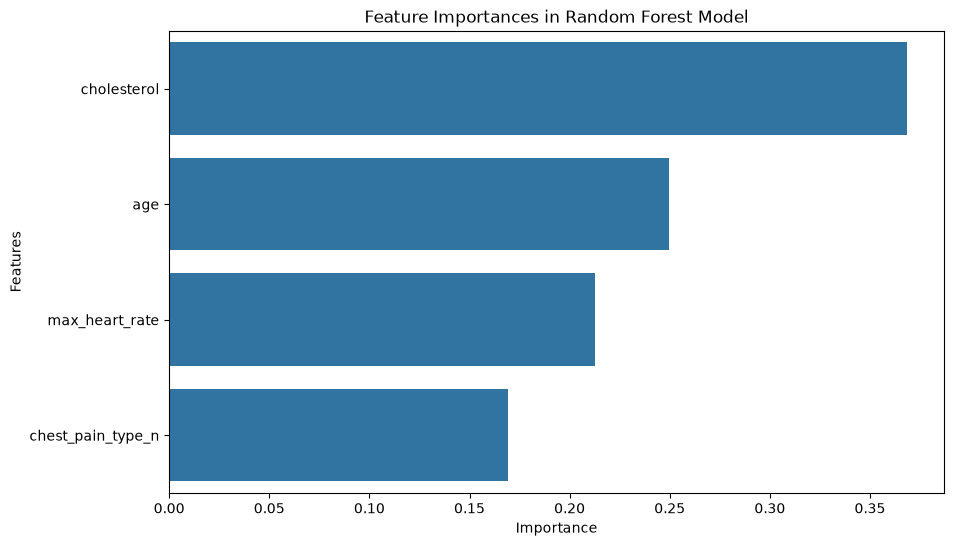

In [10]:
feature_importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=feature_importances.index)
plt.title('Feature Importances in Random Forest Model')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()